# Churn Pulse: Customer Churn Analysis and Prediction

## Problem Statement

Many customers leave the service over time.  
This project helps understand why customers churn and which customer groups need more attention.

### *import library/pakage*

In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

# **INTRODUCTION TO DATA**

### *IMPORT THE DATASET*

In [13]:
data =pd.read_csv("telco_customer_churn_eda_practice.csv")

In [14]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
data.shape

(7043, 21)

## Data Information

- **Rows:** 7,043
- **Columns:** 21
- **Target Variable:** Churn

In [16]:
data.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2994,8046-DNVTL,Male,0,Yes,No,62,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Credit card (automatic),38.60,2345.55,No
4217,8107-KNCIM,Male,1,Yes,No,14,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.10,1013.35,No
2877,0310-MVLET,Female,0,Yes,Yes,61,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.15,6010.05,Yes
1955,0701-RFGFI,Female,0,Yes,Yes,49,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),95.40,4613.95,No
5398,3936-QQFLL,Male,0,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.75,39.3,No


# **TARGET:CHURN**

In [17]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# **DUPLICATE AND UNIQUE VALUE CHECK**

In [18]:
data.duplicated().sum()

np.int64(0)

## *from this extraction data seeems to be clean in term of duplication*

In [19]:
data.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

#### **DATA LOOK RICH IN TERM OF CATAGORICAL DATA**

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### **check null value**

In [21]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### **conclustion** - DATA IS CLEAN ,THERE IS NO NULL VALUE PRESENT 

#### **IMPORTANT TIP** :**ALWAYS CONVERT  COLUMN  TO LOWER CASE**

In [22]:
data.columns =data.columns.str.lower()

In [23]:
data.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

# SEPRATE THE COLUMNS

In [24]:
target =[""]

# **UNIVARIATE ON TARGET COLUMN**

In [25]:
data["churn"].sample(10)

4805     No
1092     No
220     Yes
5491     No
3399     No
4422     No
2910     No
6537    Yes
2871    Yes
5503     No
Name: churn, dtype: object

### **UNIVARIATE - CATAGORICAL DATA  - USE COUNTPLOT ,BARPLOT ,PIECHART**

In [26]:
data["churn"].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

## **PERCENTAGE**

In [27]:
data["churn"].value_counts(normalize =True)*100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### **CONCLUSTION** : ***DETERMINED THAT CHURN PERCENTAGE :26% ,NEED STRICT OBSERVATION***


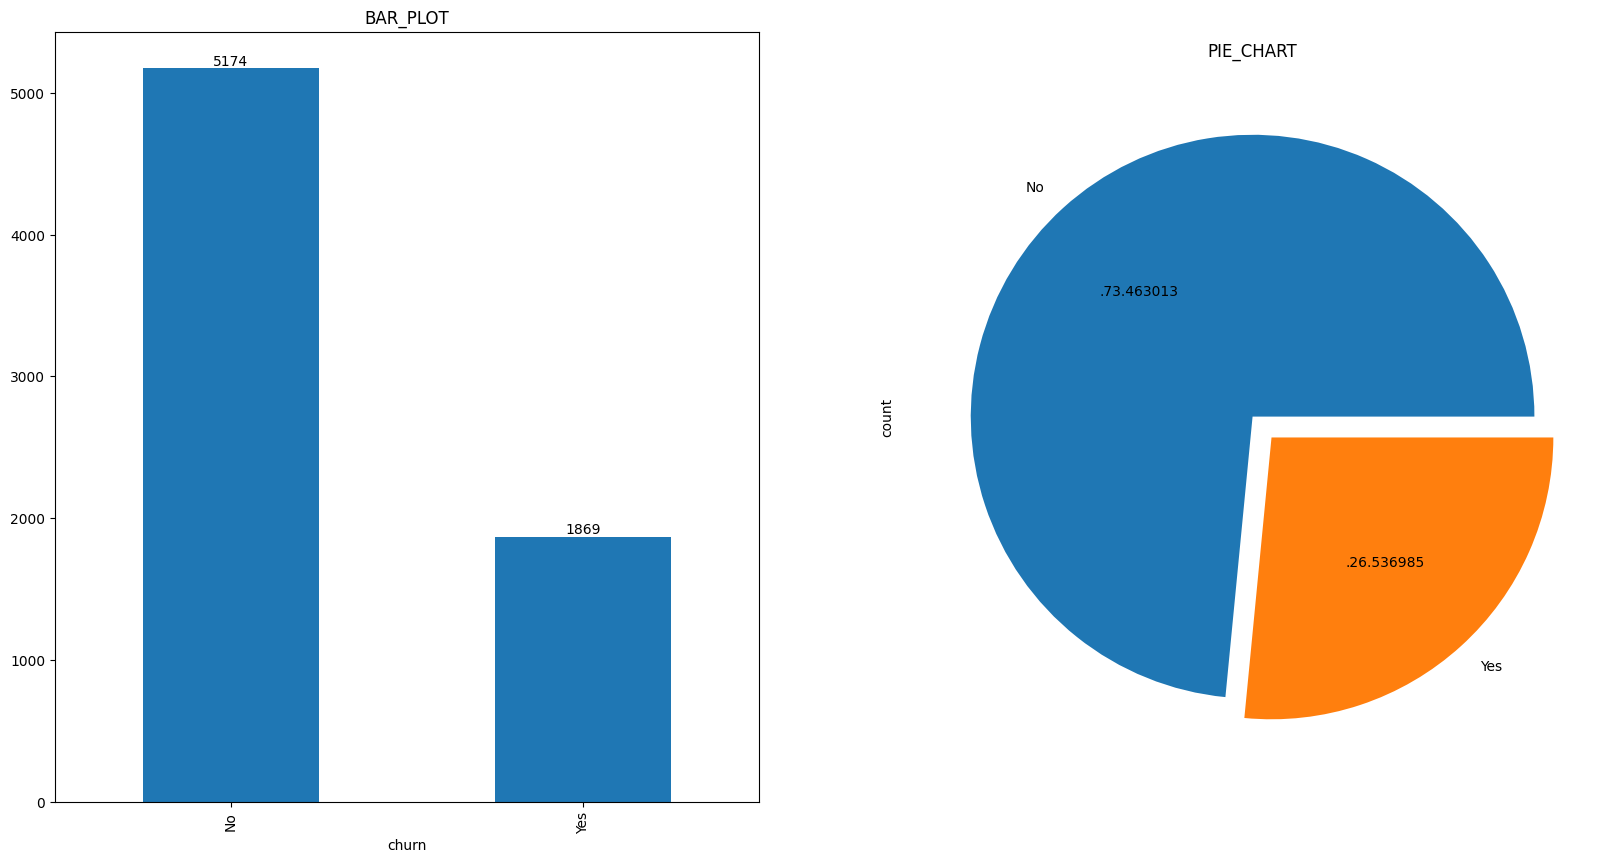

In [28]:
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
ax =data["churn"].value_counts().plot(kind="bar")
ax.bar_label(ax.containers[0])
plt.title("BAR_PLOT")

plt.subplot(1,2,2)
data["churn"].value_counts().plot(kind="pie",autopct='.%2f',explode =(0,0.1))
plt.title("PIE_CHART")
plt.savefig("images/churn_analysis")



##### **ABOUT 1869 PEOPLE OUT OF 7043 CHURN WHICH IS APPROX 26.5%** 

In [29]:
data.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [30]:
data =data.drop("customerid",axis=1)

In [31]:
# seprate catagorical columns and numerical_columns

In [32]:
data.dtypes

gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

### observed data_type error in the data present in column :**totalcharges**




In [33]:
data["totalcharges"]=pd.to_numeric(data["totalcharges"],errors="coerce")

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   object 
 6   multiplelines     7043 non-null   object 
 7   internetservice   7043 non-null   object 
 8   onlinesecurity    7043 non-null   object 
 9   onlinebackup      7043 non-null   object 
 10  deviceprotection  7043 non-null   object 
 11  techsupport       7043 non-null   object 
 12  streamingtv       7043 non-null   object 
 13  streamingmovies   7043 non-null   object 
 14  contract          7043 non-null   object 
 15  paperlessbilling  7043 non-null   object 
 16  paymentmethod     7043 non-null   object 


In [35]:
cat_col = []
for i in data.columns:
    if data[i].dtype=="O":
        cat_col.append(i)

In [36]:
num_col = []
for i in data.columns:
    if data[i].dtype!="O":
        num_col.append(i)

In [37]:
cat_col

['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'churn']

### ***CONCLUSTIONS RELATED TO CATAGORICAL DATA***

In [38]:
data["gender"].value_counts(normalize=True)*100

gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

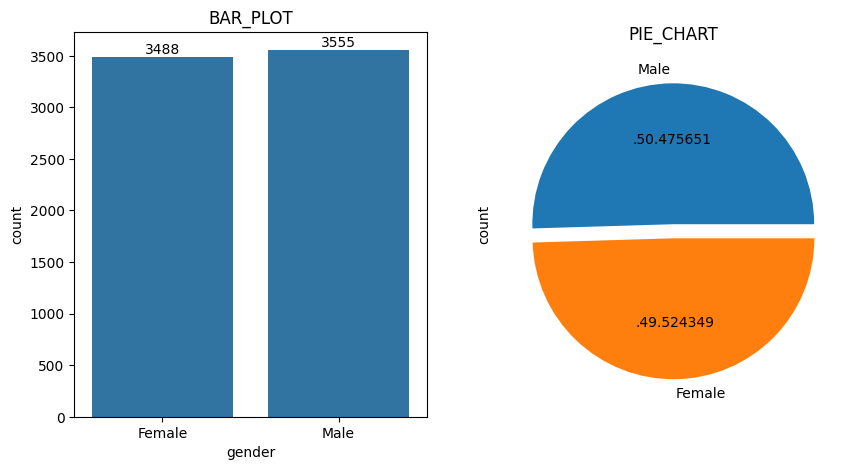

In [53]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
ax =sns.countplot(x="gender",data=data)
ax.bar_label(ax.containers[0])
plt.title("BAR_PLOT")

plt.subplot(1,2,2)
data["gender"].value_counts().plot(kind="pie",autopct='.%2f',explode =(0,0.1))
plt.title("PIE_CHART")
plt.savefig("images/gender_analysis")


### **Obsereved approcimate same number of ratio among gender i.e male and female**

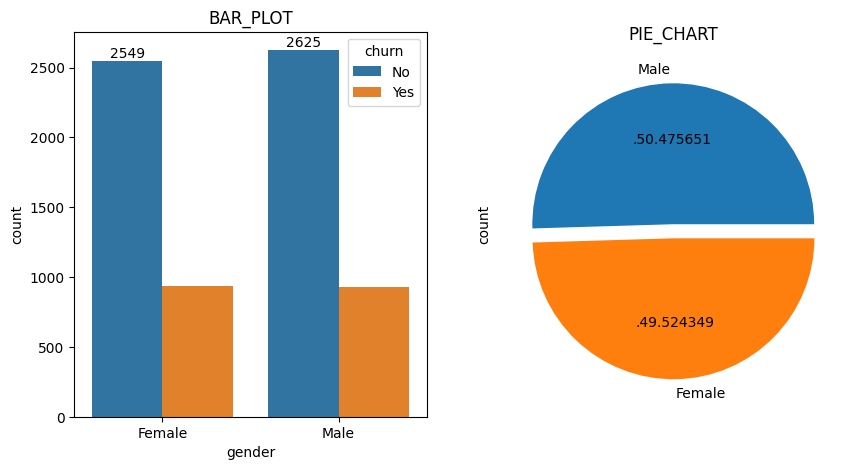

In [54]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
ax =sns.countplot(x="gender",data=data,hue="churn")
ax.bar_label(ax.containers[0])
plt.title("BAR_PLOT")

plt.subplot(1,2,2)
data["gender"].value_counts().plot(kind="pie",autopct='.%2f',explode =(0,0.1))
plt.title("PIE_CHART")
plt.savefig("images/churn_gender_analysis")


In [41]:
pd.crosstab(data["gender"],data["churn"],normalize="index")*100

churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


#### Gender-wise churn is close to the baseline(26.5), so gender does not show a major impact on customer churn.


In [42]:
data["phoneservice"].value_counts()

phoneservice
Yes    6361
No      682
Name: count, dtype: int64

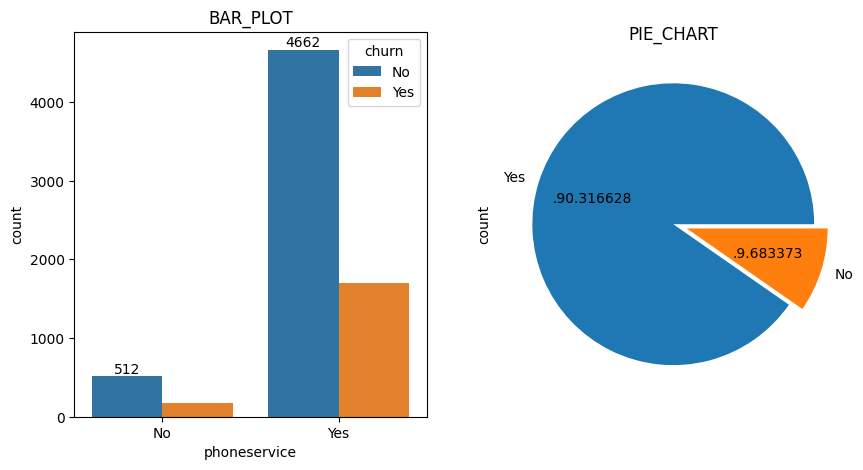

In [55]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
ax =sns.countplot(x="phoneservice",data=data,hue="churn")
ax.bar_label(ax.containers[0])
plt.title("BAR_PLOT")

plt.subplot(1,2,2)
data["phoneservice"].value_counts().plot(kind="pie",autopct='.%2f',explode =(0,0.1))
plt.title("PIE_CHART")
plt.savefig("images/churn_phone_service")

In [44]:
pd.crosstab(data["phoneservice"],data["churn"],normalize="index")*100

churn,No,Yes
phoneservice,,
No,75.073314,24.926686
Yes,73.290363,26.709637


# OBSERVED NO MAJOR INDICATOR FROM THIS "phoneservice" COLUMN 

In [45]:
cat_col

['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'churn']

In [46]:
pd.crosstab(data[ 'multiplelines'],data["churn"],normalize="index")*100

churn,No,Yes
multiplelines,,
No,74.955752,25.044248
No phone service,75.073314,24.926686
Yes,71.390104,28.609896


Customers with multiple lines show a churn rate of 28.6%, which is around 2.1 percentage points higher than the overall churn baseline of 26.5%. However, the difference is not very large, so multiple lines may have a slight churn impact but does not appear to be a strong churn driver.

In [47]:
pd.crosstab(data[ 'internetservice'],data["churn"],normalize="index")*100

churn,No,Yes
internetservice,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### **Action needed** : Found customer using fiber optic internetservice having high impact on churn rate that is 15% more then the base line 

In [48]:
pd.crosstab(data["onlinesecurity"],data["churn"],normalize="index")*100

churn,No,Yes
onlinesecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


### **Action needed** : Found customer with no  online service  having high impact on churn rate that is 15% more then the base line .suggested to focus more on security 

In [49]:
data.sample(5)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
4376,Female,0,No,No,45,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,One year,Yes,Electronic check,100.30,4483.95,No
4712,Male,0,Yes,Yes,50,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,One year,Yes,Electronic check,108.25,5431.40,No
5868,Female,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,44.00,44.00,No
2550,Female,0,Yes,Yes,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.05,1090.10,No
4634,Female,0,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),18.75,53.15,No


In [50]:
DF=pd.crosstab(data["seniorcitizen"],data["onlinesecurity"],normalize="index")*100

In [51]:
data

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [52]:
# ax=sns.countplot(x="onlinesecurity",data=data,hue="seniorcitizen")
sns.countplot("onlinesecurity","seniorcitizen",data=data,hue="churn")

for i in ax.containers:
    ax.bar_label(i)

TypeError: countplot() got multiple values for argument 'data'

# **CONCLUSTION** : YOUNGSTER FOCUS MORE ON SECURITY ABOUT 30% OF THE YOUNGSTER HAVE SECURITY 

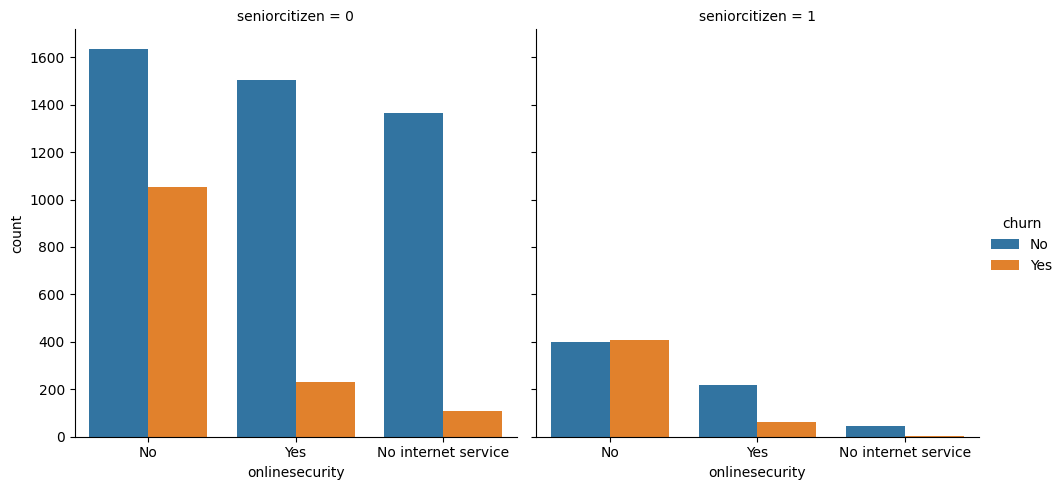

<Figure size 640x480 with 0 Axes>

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    x="onlinesecurity",
    data=data,
    hue="churn",
    col="seniorcitizen",
    kind="count",
    height=5,
    aspect=1
)

plt.show()
plt.savefig("images/senior_citizen_with_security")

In [ ]:
data.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [ ]:
data.sample(5)

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
588,Male,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,No,Yes,Two year,Yes,Electronic check,99.15,7422.1,No
4653,Female,0,Yes,Yes,30,No,No phone service,DSL,No,No,No,Yes,Yes,Yes,Month-to-month,No,Credit card (automatic),51.20,1561.5,Yes
961,Male,0,No,No,17,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,20.50,365.8,No
2500,Male,0,Yes,Yes,50,Yes,No,DSL,Yes,No,No,Yes,Yes,Yes,One year,No,Electronic check,75.50,4025.6,No
3790,Male,0,No,No,2,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.30,28.3,Yes


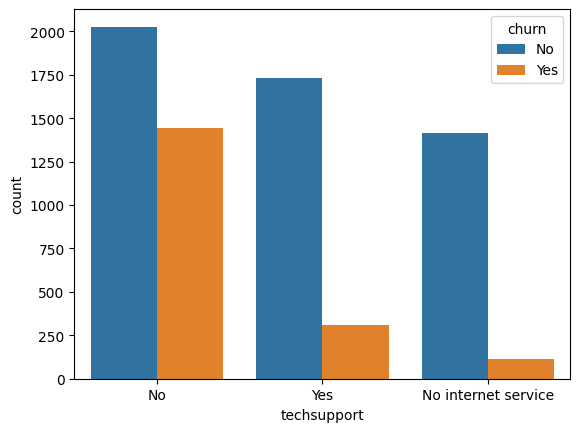

In [57]:
sns.countplot(x="techsupport",data=data,hue="churn")
plt.savefig("images/churn_techsupport")

In [ ]:
pd.crosstab(data["techsupport"],data["churn"],normalize="index")*100

churn,No,Yes
techsupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [ ]:
pd.crosstab(data["techsupport"],data["churn"])

churn,No,Yes
techsupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


### **strick action need ,found people with no techsupport churn approx 41% which is 16% up from the baseline**

In [ ]:
pd.crosstab(index=[data["techsupport"],data["seniorcitizen"]],columns=data["churn"])

churn                                No   Yes
techsupport         seniorcitizen            
No                  0              1617  1026
                    1               410   420
No internet service 0              1366   108
                    1                47     5
Yes                 0              1525   259
                    1               209    51

##### **ABOUT 1026 CUSTOMER ARE NOT SENIORCITIZEN WITH NO TECH SUPPORT ,SUGGESTED TO LAUNCH AUTOMATED TECH SUPPORT IN THE CATAGORY OF NON SENIOR CITIZEN** *focus more on young catagory*

In [ ]:
data.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [ ]:
pd.crosstab([data["onlinebackup"],data["seniorcitizen"],data["gender"]],data["churn"],normalize="index")*100

churn                                            No        Yes
onlinebackup        seniorcitizen gender                      
No                  0             Female  62.355848  37.644152
                                  Male    64.126984  35.873016
                    1             Female  46.511628  53.488372
                                  Male    47.923323  52.076677
No internet service 0             Female  92.699725   7.300275
                                  Male    92.647059   7.352941
                    1             Female  85.714286  14.285714
                                  Male    93.548387   6.451613
Yes                 0             Female  80.714286  19.285714
                                  Male    80.781089  19.218911
                    1             Female  69.105691  30.894309
                                  Male    69.130435  30.869565

**Recommended backup support options for senior citizen customers to reduce churn risk and improve service reliability, while gender showed no major difference in churn behavior or service experience.**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(
    [data["onlinebackup"], data["seniorcitizen"], data["gender"]],
    data["churn"],
    normalize="index"
) * 100

ct = ct.reset_index()

ct_melted = ct.melt(
    id_vars=["onlinebackup", "seniorcitizen", "gender"],
    value_vars=["No", "Yes"],
    var_name="churn",
    value_name="percentage"
)

sns.catplot(
    data=ct_melted,
    x="onlinebackup",
    y="percentage",
    hue="churn",
    col="seniorcitizen",
    row="gender",
    kind="bar",
    height=4,
    aspect=1.4
)

plt.show()

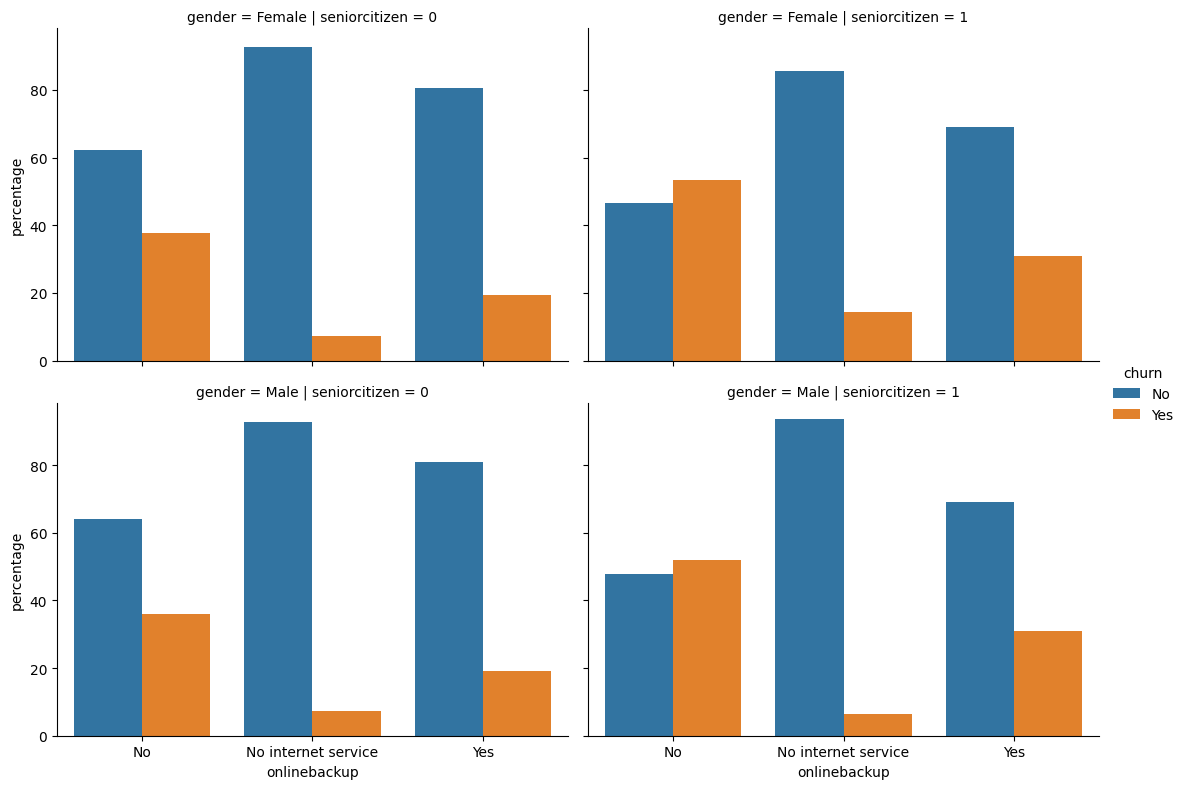

In [ ]:
#import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(
    [data["onlinebackup"], data["seniorcitizen"], data["gender"]],
    data["churn"],
    normalize="index"
) * 100

ct = ct.reset_index()

ct_melted = ct.melt(
    id_vars=["onlinebackup", "seniorcitizen", "gender"],
    value_vars=["No", "Yes"],
    var_name="churn",
    value_name="percentage"
)

sns.catplot(
    data=ct_melted,
    x="onlinebackup",
    y="percentage",
    hue="churn",
    col="seniorcitizen",
    row="gender",
    kind="bar",
    height=4,
    aspect=1.4
)

plt.show()

In [ ]:
data.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [ ]:
pd.crosstab([data["streamingmovies"],data["streamingtv"],data["seniorcitizen"]],data["churn"],normalize="index")*100

churn                                                         No        Yes
streamingmovies     streamingtv         seniorcitizen                      
No                  No                  0              68.364290  31.635710
                                        1              52.148997  47.851003
                    Yes                 0              70.531401  29.468599
                                        1              58.904110  41.095890
No internet service No internet service 0              92.672999   7.327001
                                        1              90.384615   9.615385
Yes                 No                  0              72.391653  27.608347
                                        1              55.621302  44.378698
                    Yes                 0              73.447820  26.552180
                                        1              60.328638  39.671362

### Conclusion

Senior citizens with both Streaming Movies and Streaming TV subscriptions showed a higher churn rate than non-senior customers in the same subscription segment. Non-senior customers were close to the overall churn baseline of 26.55%, while senior citizens were significantly above the baseline.

This suggests that streaming service subscriptions alone do not strongly increase churn among younger/non-senior customers, but senior citizens remain a higher-risk churn segment even when they use both entertainment services.

### Recommended Action

Focus retention efforts on senior citizen customers by offering senior-friendly support, personalized service plans, simplified subscription guidance, or targeted discount offers to reduce churn risk.

# **Numerical columns**

In [ ]:
num_col.remove("seniorcitizen")

ValueError: list.remove(x): x not in list

In [ ]:
num_col

['tenure', 'monthlycharges', 'totalcharges']

In [ ]:
data["tenure"].sample(10) # tenure is in month 

1246    45
5070    35
2815     3
1224     1
1528    19
1297     5
988     27
2929    40
3696     6
2646    56
Name: tenure, dtype: int64

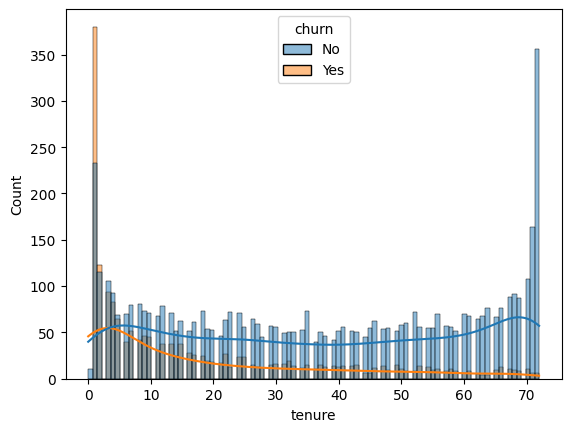

In [58]:
sns.histplot(x="tenure",data=data,kde=True,hue="churn",bins=100) #  note : hue only work with this format 
plt.savefig("images/tenure_churn")

In [ ]:
pd.crosstab(data["tenure"],data["churn"],)

churn,No,Yes
tenure,,
0,11,0
1,233,380
2,115,123
3,106,94
4,93,83
...,...,...
68,91,9
69,87,8
70,108,11


tenure_group
0-6 Months      1470
7-12 Months      705
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: count, dtype: int64
churn                No        Yes
tenure_group                      
0-6 Months    46.666667  53.333333
7-12 Months   64.113475  35.886525
13-24 Months  71.289062  28.710938
25-48 Months  79.611041  20.388959
49-72 Months  90.486824   9.513176


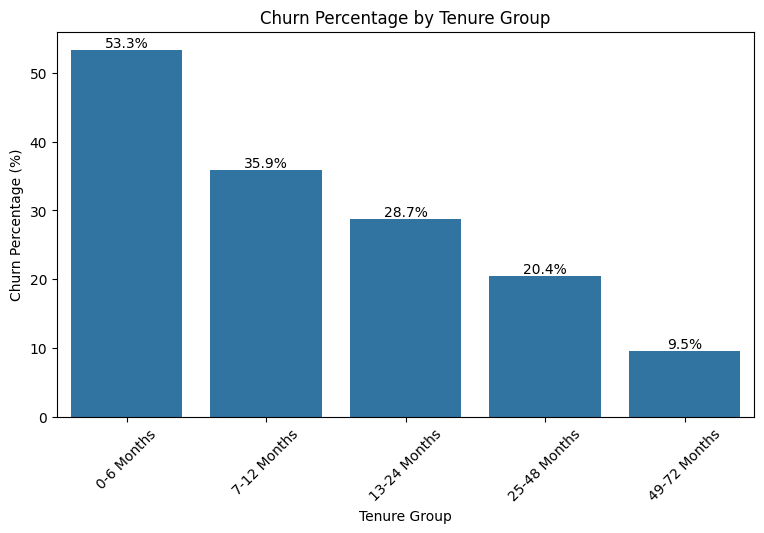

<Figure size 640x480 with 0 Axes>

In [59]:

# 1. Create tenure groups using pd.cut()
data["tenure_group"] = pd.cut(
    data["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

# 2. Check tenure groups
print(data["tenure_group"].value_counts().sort_index())

# 3. Create churn percentage table
tenure_churn = pd.crosstab(
    data["tenure_group"],
    data["churn"],
    normalize="index"
) * 100

# 4. Show churn percentage table
print(tenure_churn)

# 5. Plot only churn percentage
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn["Yes"]
)

plt.title("Churn Percentage by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Percentage (%)")
plt.xticks(rotation=45)

# 6. Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()
plt.savefig("images/month_wise_tenure_churn")

**CONCLUSTION**

  ***ANALYSED PERSON CHURNING OUT WITHIN 2-3 MONTH OF JOINING,RECOMMENDED TO PROVIDE BETTER SCHEME OPTION TO THE NEW CUSTOMER,TRY TO PROVIDE YEARLY MEMEMBERSHIP***


In [ ]:
pd.crosstab(
    data["tenure_group"],
    data["churn"],
    normalize="index"
) * 100

churn,No,Yes
tenure_group,,
0-6 Months,46.666667,53.333333
7-12 Months,64.113475,35.886525
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


In [ ]:
num_col

['tenure', 'monthlycharges', 'totalcharges']

In [ ]:
data["monthlycharges"].value_counts()

monthlycharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
56.85      1
101.70     1
48.40      1
108.35     1
72.00      1
Name: count, Length: 1585, dtype: int64

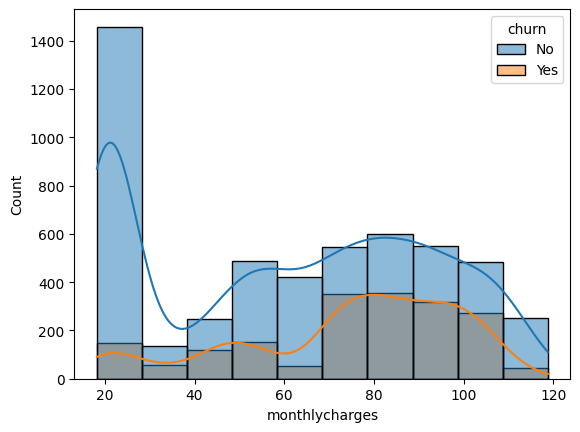

In [61]:
sns.histplot(x="monthlycharges",data=data,kde=True,bins=10,hue="churn")
plt.savefig("images/monthly_churn_with_charges")

In [ ]:
data["monthlycharges"].min()

np.float64(18.25)

### **MAJORITY CUSTOMER (1600 ) RECHARGE RANGE IS BETWEEN 18.5 TO 30** ,there is no effect of monthly recharge to the churn ratio 

SNS

In [ ]:
data["monthlycharges"]=pd.cut(data["monthlycharges"],bins=[18,30,40,50,60,70,80,90,100,110,120],labels=["18-30","30-40","40-50","50-60","60-70","70-80","80-90","90-100","100-110","110-120"])

In [ ]:
data["monthlycharges"].value_counts(normalize=True)*100

monthlycharges
18-30      23.470112
80-90      13.162005
70-80      13.020020
90-100     11.884140
100-110     9.754366
50-60       8.788868
60-70       7.695584
40-50       6.545506
110-120     3.052676
30-40       2.626722
Name: proportion, dtype: float64

In [ ]:
pd.crosstab(data["monthlycharges"],data["churn"],normalize="index")*100

churn,No,Yes
monthlycharges,,
18-30,90.199637,9.800363
30-40,71.891892,28.108108
40-50,68.112798,31.887202
50-60,79.159935,20.840065
60-70,79.335793,20.664207
70-80,60.632497,39.367503
80-90,63.754045,36.245955
90-100,62.126643,37.873357
100-110,67.248908,32.751092


### Conclusion

Monthly charges appear to have an impact on churn. Customers in the 18-30 monthly charge range show very low churn at around 9.8%, which is far below the overall churn baseline of 26.55%.

However, customers in the 70-100 monthly charge range show much higher churn, around 36% to 39%, which is significantly above the baseline. This suggests that customers paying higher monthly charges may be more sensitive to pricing or may not feel they are receiving enough value for the cost.

### Recommended Action

Focus retention strategies on customers in the 70-100 monthly charge range by offering personalized discounts, value-added service bundles, loyalty benefits, or plan optimization support.

In [ ]:
data["churn"]

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: churn, Length: 7043, dtype: object

### "ENCODING"

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
obj = OrdinalEncoder(categories=[["Yes","No"]])
obj.fit(data[["churn"]])
array =obj.transform(data[["churn"]])
data["churn"]=pd.DataFrame(array,columns=["churn"])


ValueError: could not convert string to float: 'Yes'

In [ ]:
data[["churn"]]

,churn
0,1.0
1,1.0
2,0.0
3,1.0
4,0.0
...,...
7038,1.0
7039,1.0
7040,1.0
7041,0.0


In [ ]:
data.corr(numeric_only=True)

,seniorcitizen,tenure,totalcharges,churn
seniorcitizen,1.000000,0.016567,0.102411,-0.150889
tenure,0.016567,1.000000,0.825880,0.352229
totalcharges,0.102411,0.825880,1.000000,0.199484
churn,-0.150889,0.352229,0.199484,1.000000


In [ ]:
import os 


In [ ]:
os.makedirs("images",exist_ok =True)